In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

Accuracy

Dataset shape (400, 4)

Accuracy 0.9

Classifcation Report:

              precision    recall  f1-score   support

           0       0.91      0.94      0.92        63
           1       0.89      0.84      0.86        37

    accuracy                           0.90       100
   macro avg       0.90      0.89      0.89       100
weighted avg       0.90      0.90      0.90       100

Confusion Matrix:
 [[59  4]
 [ 6 31]]


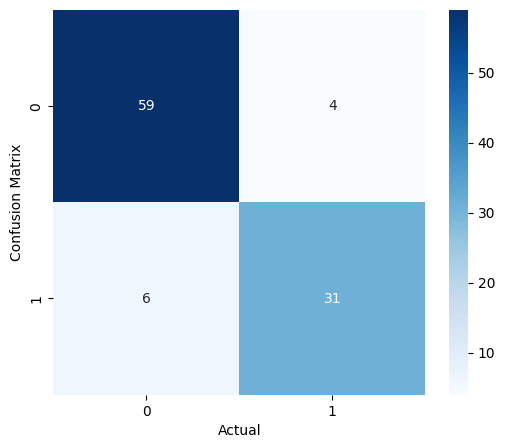

In [12]:
df = pd.read_csv('/workspaces/SML/SML /iphone_purchase_records.csv')
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values
print("Dataset shape",df.shape)

LabelEncoder_gender = LabelEncoder()
X[:,0]=LabelEncoder_gender.fit_transform(X[:,0])
#Convert to float
X = X.astype(float)
X_train, X_test,y_train, y_test= train_test_split(X,y,test_size=0.25,random_state=42)
classifier = DecisionTreeClassifier(
    criterion='entropy',
    max_depth = 4,
    random_state= 42
)
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print("\nAccuracy",accuracy)
print("\nClassifcation Report:\n")
print(classification_report(y_test,y_pred))

cm =confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n",cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt = 'd',cmap = 'Blues')
plt.xlabel("Actual")
plt.ylabel("Confusion Matrix")
plt.show()

Train and Test Accuracy

In [11]:
from sklearn.metrics import accuracy_score, classification_report

# --- Training Results ---
y_train_pred = classifier.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

print("--- TRAINING RESULTS ---")
print(f"Training Accuracy: {train_accuracy:.4f}")
print("\nTraining Classification Report:\n")
print(classification_report(y_train, y_train_pred))

print("-" * 30)

# --- Test Results ---
# y_pred is already calculated in your code for X_test
test_accuracy = accuracy_score(y_test, y_pred)

print("--- TEST RESULTS ---")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nTest Classification Report:\n")
print(classification_report(y_test, y_pred))

--- TRAINING RESULTS ---
Training Accuracy: 0.9767

Training Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       194
           1       0.98      0.95      0.97       106

    accuracy                           0.98       300
   macro avg       0.98      0.97      0.97       300
weighted avg       0.98      0.98      0.98       300

------------------------------
--- TEST RESULTS ---
Test Accuracy: 0.8700

Test Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.92      0.90        63
           1       0.85      0.78      0.82        37

    accuracy                           0.87       100
   macro avg       0.87      0.85      0.86       100
weighted avg       0.87      0.87      0.87       100



PLOTTING THE TREE

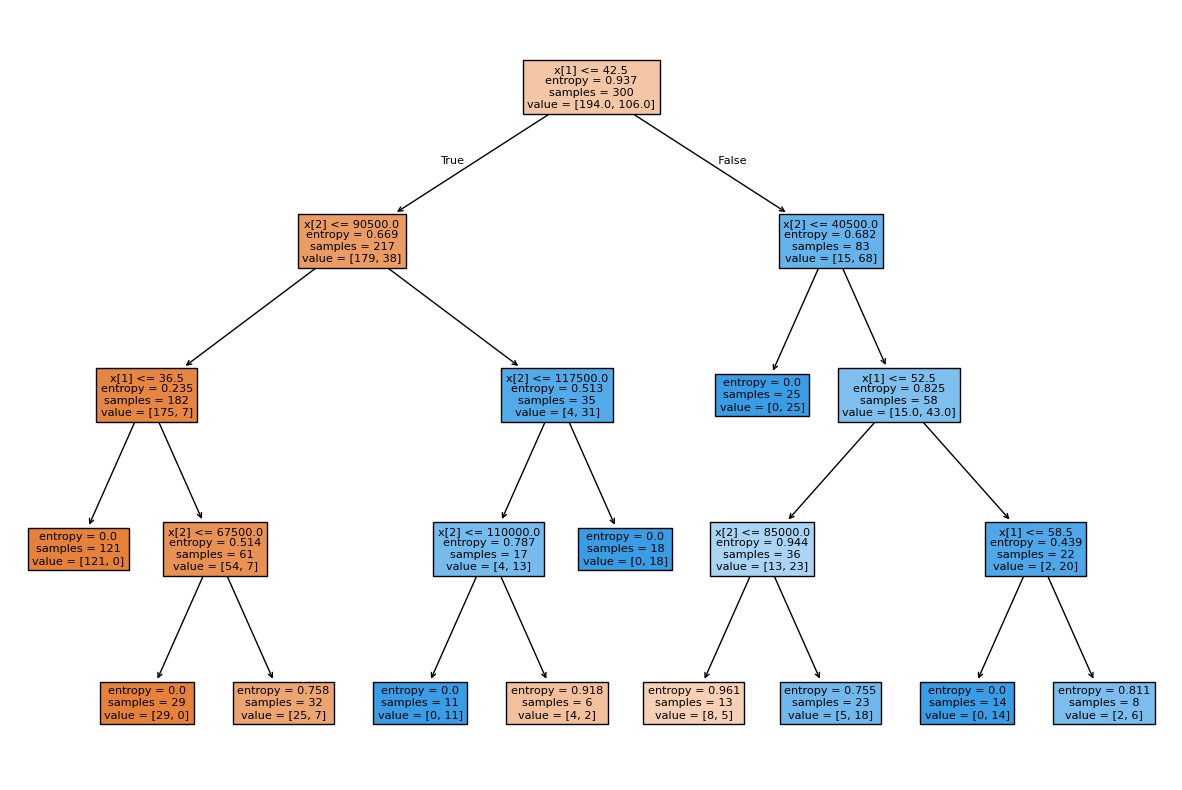

In [8]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(classifier,filled=True)
plt.show()